In [50]:
# KONFIGURACJA ŚRODOWISKA + IMPORTY

import os
import sys

# Dodajemy folder główny projektu do ścieżki, aby zaimportować nasze narzędzia
sciezka_glowna = os.path.abspath('..')
if sciezka_glowna not in sys.path:
    sys.path.append(sciezka_glowna)

from pipeline.utils import wczytaj_dane, polacz_dane, tabela_korelacji, wykres_korelacji
import pandas as pd
%matplotlib inline

print("Narzędzia analityczne gotowe do pracy! 🚀")

Narzędzia analityczne gotowe do pracy! 🚀


## 🌍 Krok 1: Pobieranie wszystkich danych

Pobieramy nasze zbiory danych z GitHuba. W tym notatniku spróbujemy odpowiedzieć na pytanie: **Co tak naprawdę wpływa na nasze poczucie szczęścia i zamożność kraju?**

In [51]:
BAZA_URL = "https://raw.githubusercontent.com/tadejow/warsztaty-wizualizacja-danych/main/data/"

print("Pobieranie danych w toku...\n")
df_costs     = wczytaj_dane(BAZA_URL + "costs_of_living_index.csv")
df_crime     = wczytaj_dane(BAZA_URL + "crime_index.csv")
df_economy   = wczytaj_dane(BAZA_URL + "economy_index.csv")
df_happiness = wczytaj_dane(BAZA_URL + "happiness_index.csv")
df_health    = wczytaj_dane(BAZA_URL + "health_index.csv")
df_pollution = wczytaj_dane(BAZA_URL + "pollution_index.csv")
df_property  = wczytaj_dane(BAZA_URL + "property_price_index.csv")
df_quality   = wczytaj_dane(BAZA_URL + "quality_of_life_index.csv")
df_traffic   = wczytaj_dane(BAZA_URL + "traffic_index.csv")
df_world     = wczytaj_dane(BAZA_URL + "world_data.csv")
print("\n✅ Wszystkie dane wczytane!")

Pobieranie danych w toku...

Wczytywanie danych z: https://raw.githubusercontent.com/tadejow/warsztaty-wizualizacja-danych/main/data/costs_of_living_index.csv...
Wczytywanie i wstępne czyszczenie zakończone sukcesem.
Wczytywanie danych z: https://raw.githubusercontent.com/tadejow/warsztaty-wizualizacja-danych/main/data/crime_index.csv...
Wczytywanie i wstępne czyszczenie zakończone sukcesem.
Wczytywanie danych z: https://raw.githubusercontent.com/tadejow/warsztaty-wizualizacja-danych/main/data/economy_index.csv...
Wczytywanie i wstępne czyszczenie zakończone sukcesem.
Wczytywanie danych z: https://raw.githubusercontent.com/tadejow/warsztaty-wizualizacja-danych/main/data/happiness_index.csv...
Wczytywanie i wstępne czyszczenie zakończone sukcesem.
Wczytywanie danych z: https://raw.githubusercontent.com/tadejow/warsztaty-wizualizacja-danych/main/data/health_index.csv...
Wczytywanie i wstępne czyszczenie zakończone sukcesem.
Wczytywanie danych z: https://raw.githubusercontent.com/tadejow/

## 🔗 Krok 2: Tworzenie Tabeli Bazowej i Łączenie Parami

Najpierw połączymy ogólne dane o świecie (`world_data`) z indeksem szczęścia (`happiness_index`). To będzie nasza **Tabela Bazowa**. 

Następnie, tę bazę połączymy osobno z każdym z pozostałych wskaźników (przestępczość, zdrowie itd.). Łączymy je parami, aby nie tracić państw z analizy w sytuacji, gdy jakiemuś krajowi brakuje np. tylko danych o korkach ulicznych.

In [52]:
# ==========================================
# KOMÓRKA 5: PRECYZYJNE ŁĄCZENIE DANYCH
# ==========================================

# 1. Definiujemy nasze zmienne docelowe (cele korelacji)
zmienne_docelowe = ['life_evaluation', 'gdp_per_capita']
klucz = 'country'

# 2. Tworzymy główną bazę (tu zostawiamy wszystko dla pierwszego wykresu)
print("--- Tworzenie Pełnej Tabeli Bazowej ---")
df_base = polacz_dane(dane1=df_world, dane2=df_happiness, klucz=klucz)

# 3. Przygotowujemy "odchudzoną" bazę do kolejnych połączeń.
# Bierzemy TYLKO kraj i nasze dwa cele (szczęście i PKB).
df_base_slim = df_base[[klucz] + zmienne_docelowe]

# 4. Łączymy "odchudzoną" bazę z konkretnymi zbiorami danych.
# Dzięki temu w df_base_costs znajdą się TYLKO dane o kosztach + cele korelacji.
print("\n--- Tworzenie Specjalistycznych Tabel (Tylko unikalne dane) ---")

df_base_costs     = polacz_dane(df_base_slim, df_costs,     klucz=klucz)
df_base_crime     = polacz_dane(df_base_slim, df_crime,     klucz=klucz)
df_base_health    = polacz_dane(df_base_slim, df_health,    klucz=klucz)
df_base_pollution = polacz_dane(df_base_slim, df_pollution, klucz=klucz)
df_base_quality   = polacz_dane(df_base_slim, df_quality,   klucz=klucz)
df_base_property  = polacz_dane(df_base_slim, df_property,  klucz=klucz)
df_base_traffic   = polacz_dane(df_base_slim, df_traffic,   klucz=klucz)

print("\n✅ Tabele tematyczne gotowe. Każda zawiera teraz tylko unikalne wskaźniki.")

--- Tworzenie Pełnej Tabeli Bazowej ---
Operacja łączenia danych zakończona pomyślnie.

--- Tworzenie Specjalistycznych Tabel (Tylko unikalne dane) ---
Operacja łączenia danych zakończona pomyślnie.
Operacja łączenia danych zakończona pomyślnie.
Operacja łączenia danych zakończona pomyślnie.
Operacja łączenia danych zakończona pomyślnie.
Operacja łączenia danych zakończona pomyślnie.
Operacja łączenia danych zakończona pomyślnie.
Operacja łączenia danych zakończona pomyślnie.

✅ Tabele tematyczne gotowe. Każda zawiera teraz tylko unikalne wskaźniki.


## 📈 Krok 3: Analiza Korelacji

Korelacja (współczynnik Pearsona) przyjmuje wartości od -1 do 1:
* **Blisko 1:** Silna zależność dodatnia (Gdy X rośnie, Y też rośnie).
* **Blisko -1:** Silna zależność ujemna (Gdy X rośnie, Y maleje).
* **Blisko 0:** Brak zauważalnego związku.

Sprawdźmy, co wpływa na zamożność (`gdp_per_capita`) i poczucie szczęścia (`life_evaluation`).

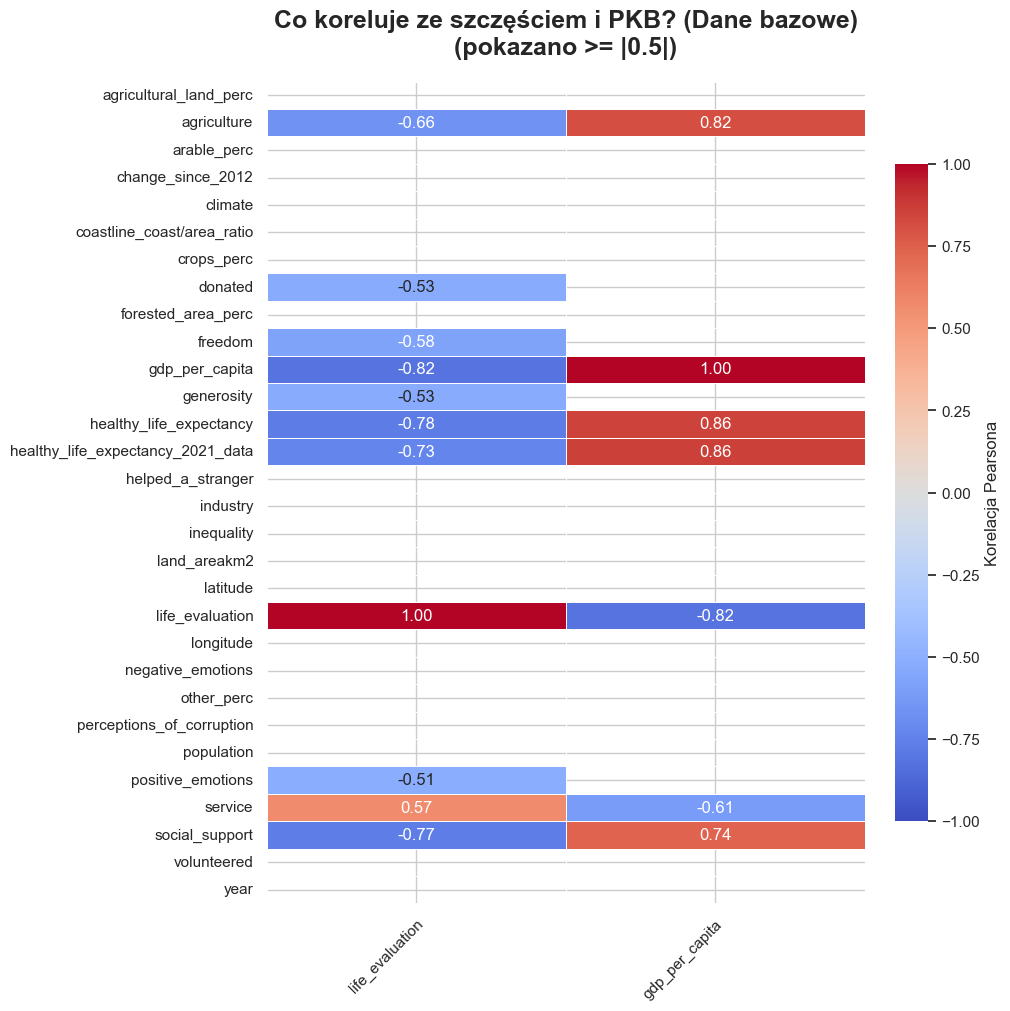

In [61]:
# Sprawdzamy, jak podstawowe wskaźniki (np. długość życia, dzietność, podatki) 
# korelują z PKB i szczęściem.

tabela_korelacji(
    dane=df_base, 
    kolumny=zmienne_docelowe,
    tytul="Co koreluje ze szczęściem i PKB? (Dane bazowe)",
    rozmiar=(10, 10), 
    prog_korelacji=0.5
)

### 💰 Koszty Życia a Szczęście
Czy wysokie koszty życia obniżają poziom szczęścia? A może wysokie koszty życia występują tylko w krajach o wysokim PKB, gdzie ludzie i tak są szczęśliwsi? Sprawdźmy to!

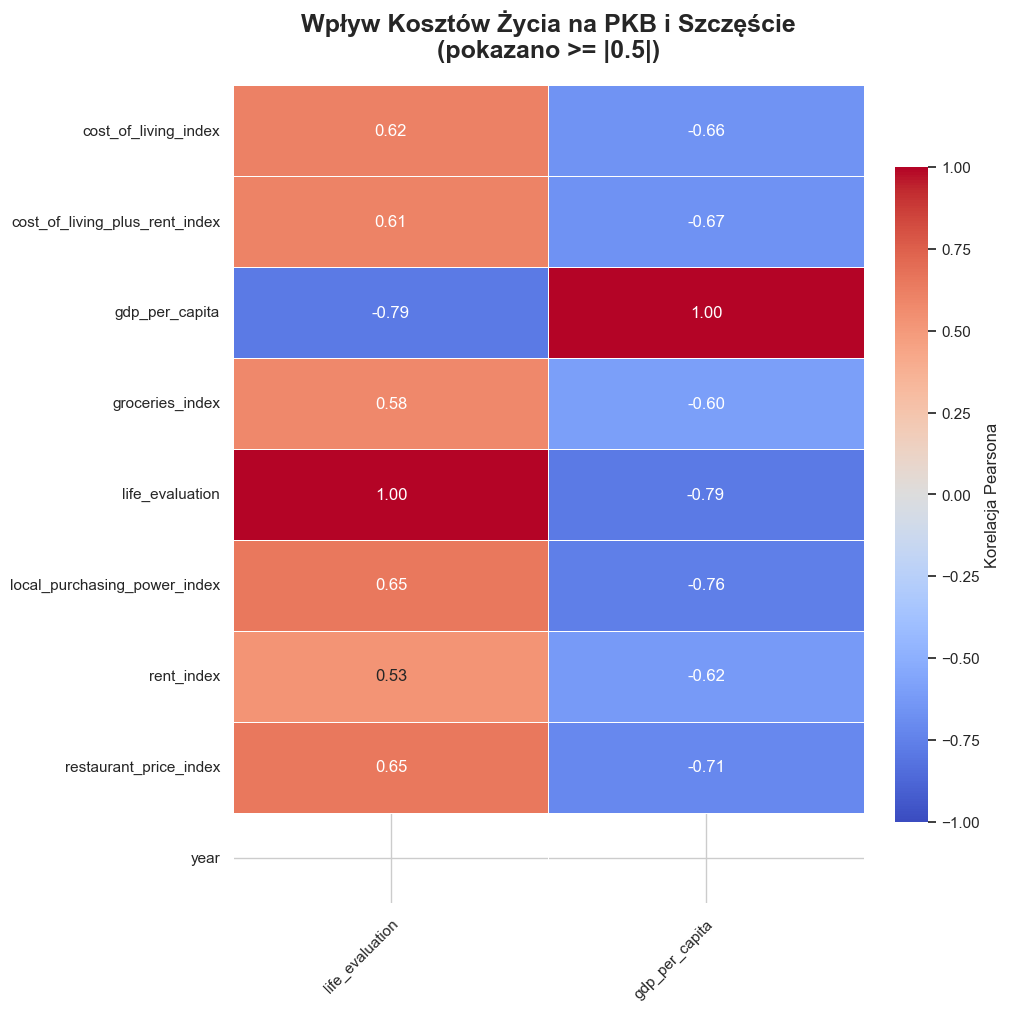

In [54]:
# ==========================================
# ANALIZA 2: Koszty życia
# ==========================================
tabela_korelacji(
    dane=df_base_costs, 
    kolumny=zmienne_docelowe,
    tytul="Wpływ Kosztów Życia na PKB i Szczęście",
    rozmiar=(10, 10),
    prog_korelacji=0.5
)

### 🏥 Zdrowie i Jakość Życia
Oczekujemy, że dobry system opieki zdrowotnej (`health_index`) silnie wpłynie na szczęście obywateli. Żeby było ciekawiej, użyjemy parametru `prog_korelacji=0.3`. Ukryje on na wykresie wszystkie słabe powiązania (pomiędzy -0.3 a 0.3), zostawiając nam tylko te najważniejsze!

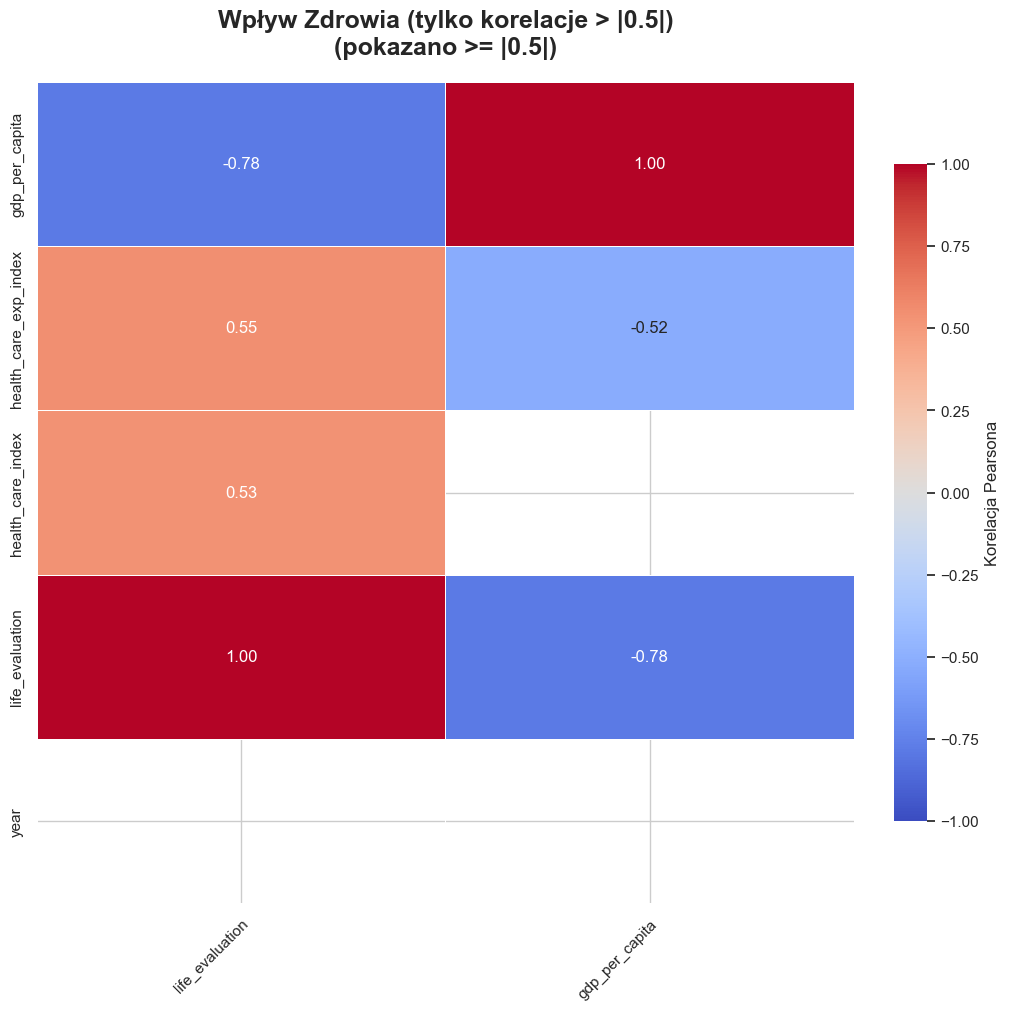

In [55]:
# ==========================================
# ANALIZA 3: Zdrowie z użyciem progu odcięcia
# ==========================================
tabela_korelacji(
    dane=df_base_health, 
    kolumny=zmienne_docelowe,
    prog_korelacji=0.5,
    tytul="Wpływ Zdrowia (tylko korelacje > |0.5|)",
    rozmiar=(10, 10)
)

### 🚨 Ciemna strona: Przestępczość i Zanieczyszczenia
Sprawdźmy teraz zjawiska negatywne. Korelacja powinna być ujemna (kolor niebieski na mapie ciepła) – im wyższa przestępczość lub smog, tym niższe szczęście.

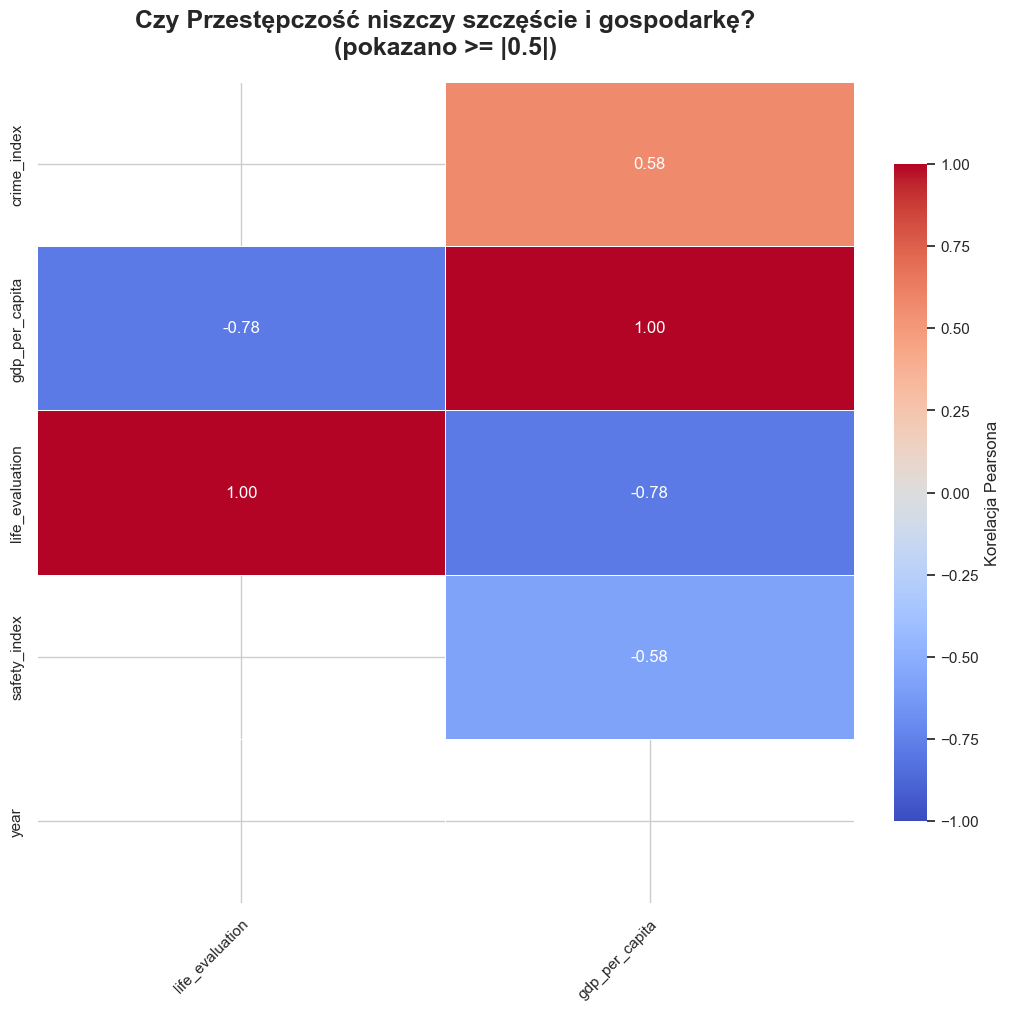

In [56]:
# ==========================================
# ANALIZA 4: Przestępczość
# ==========================================
tabela_korelacji(
    dane=df_base_crime, 
    kolumny=zmienne_docelowe,
    tytul="Czy Przestępczość niszczy szczęście i gospodarkę?",
    rozmiar=(10, 10),
    prog_korelacji=0.5
)

### 🌿 Środowisko i Zanieczyszczenia
Wiele osób twierdzi, że stan środowiska bezpośrednio przekłada się na satysfakcję z życia. Sprawdźmy, czy indeks zanieczyszczenia (`pollution_index`) wykazuje silną ujemną korelację z poczuciem szczęścia.

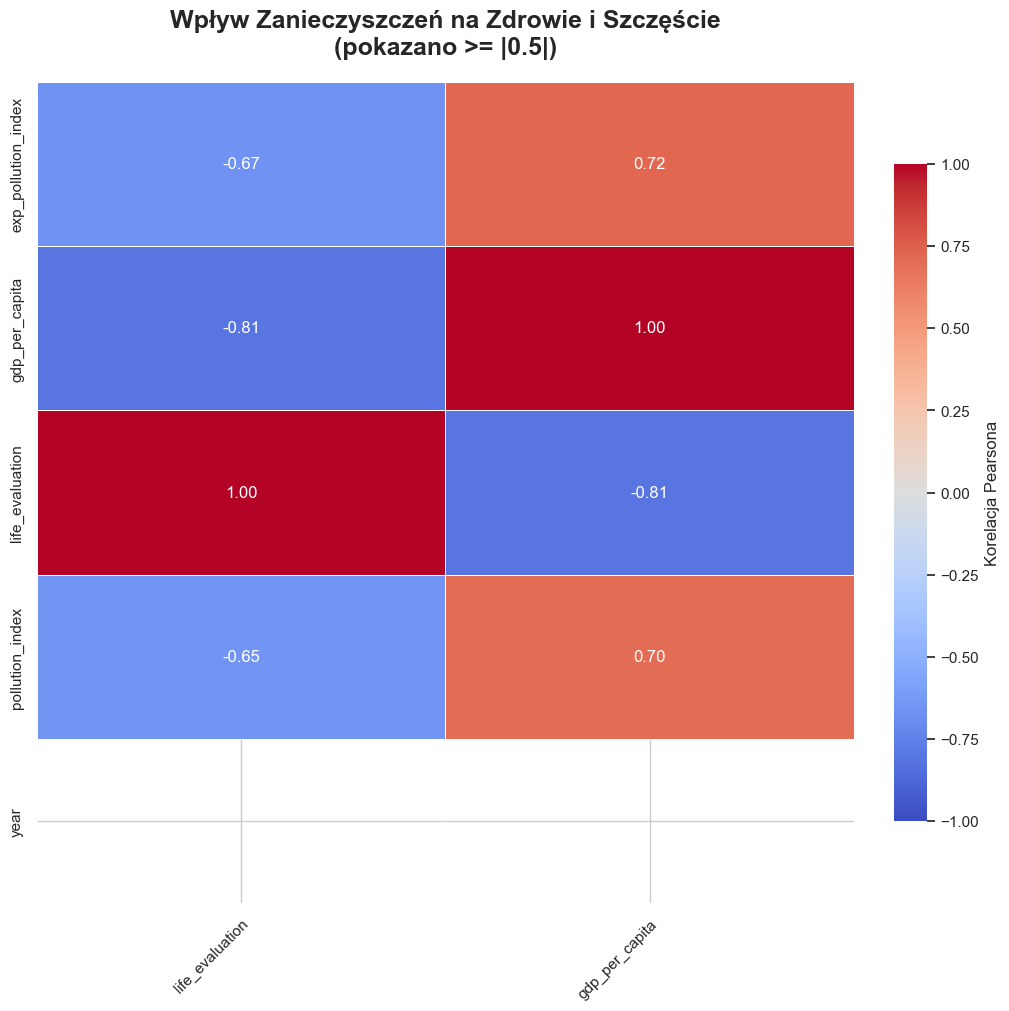

In [57]:
# ==========================================
# ANALIZA 5: Zanieczyszczenia
# ==========================================
tabela_korelacji(
    dane=df_base_pollution, 
    kolumny=zmienne_docelowe,
    tytul="Wpływ Zanieczyszczeń na Zdrowie i Szczęście",
    rozmiar=(10, 10),
    prog_korelacji=0.5
)

### 🏘️ Mieszkalnictwo i Ceny Nieruchomości
Kolejnym aspektem jest dostępność mieszkań. Sprawdzimy, czy wysoki stosunek cen nieruchomości do dochodów (`price_to_income_ratio`) koreluje ze wskaźnikami ekonomicznymi i czy wpływa na ogólną ocenę życia.

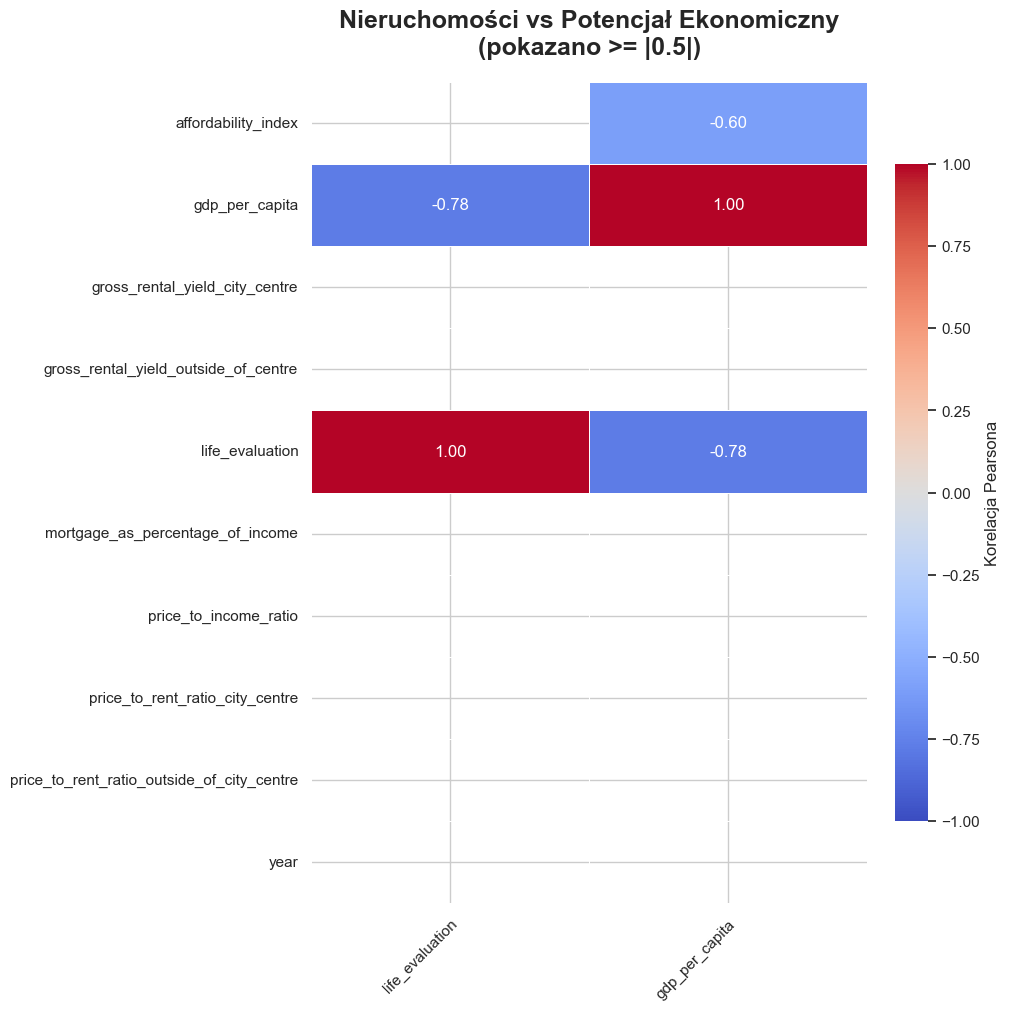

In [58]:
# ==========================================
# ANALIZA 6: Ceny Nieruchomości
# ==========================================

tabela_korelacji(
    dane=df_base_property, 
    kolumny=zmienne_docelowe,
    tytul="Nieruchomości vs Potencjał Ekonomiczny",
    rozmiar=(10, 10),
    prog_korelacji=0.5
)

### 🚦 Transport i Korki
Długie dojazdy do pracy są często wymieniane jako jeden z głównych czynników obniżających jakość życia. Przeanalizujemy dane z `traffic_index`, aby sprawdzić, czy czas spędzony w korkach (`time_index`) ma związek z oceną szczęścia.

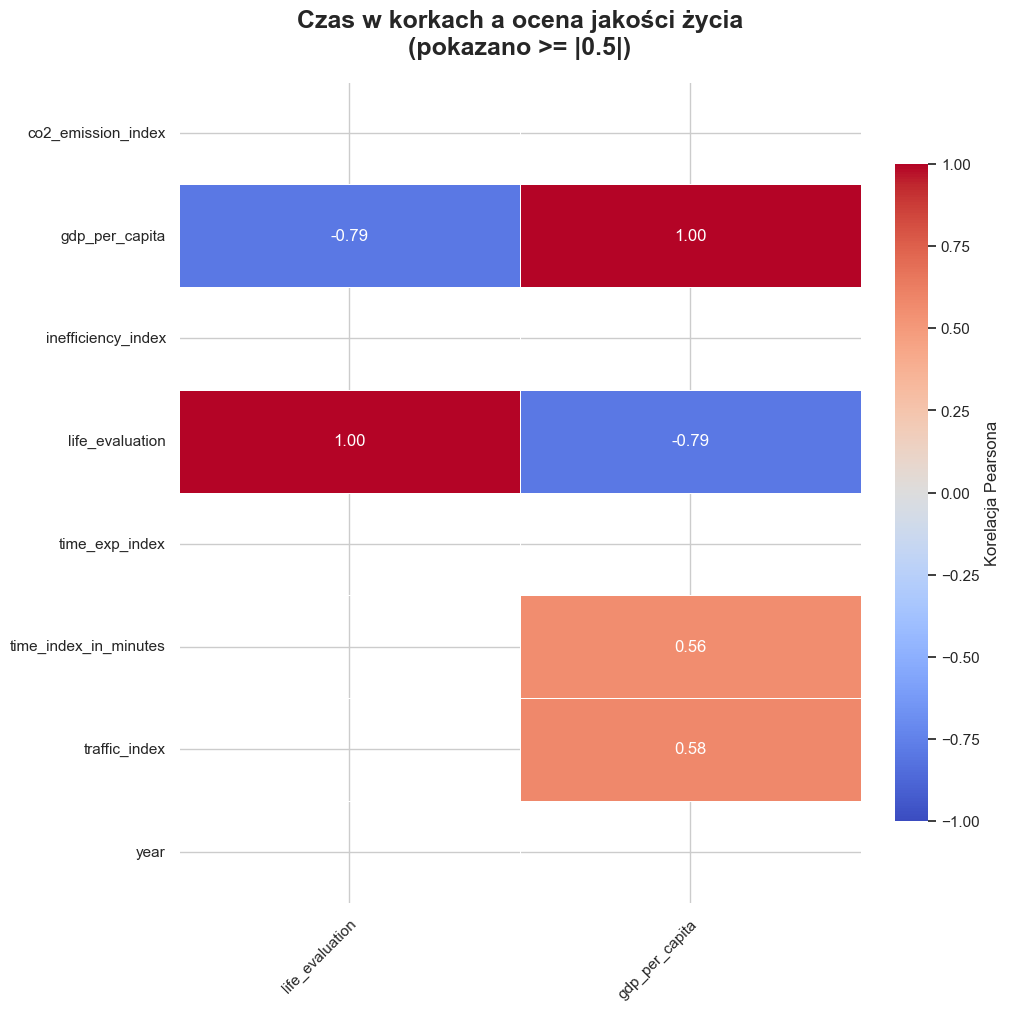

In [59]:
# ==========================================
# ANALIZA 7: Transport i Ruch Drogowy
# ==========================================

tabela_korelacji(
    dane=df_base_traffic, 
    kolumny=zmienne_docelowe,
    tytul="Czas w korkach a ocena jakości życia",
    rozmiar=(10, 10),
    prog_korelacji=0.5
)

### 💎 Jakość Życia (Suma wszystkich czynników)
Na koniec zestawimy nasze główne zmienne z indeksem jakości życia (`quality_of_life_index`), który sam w sobie jest agregatem wielu mniejszych wskaźników (siła nabywcza, bezpieczeństwo, opieka zdrowotna). Powinniśmy tu zobaczyć najsilniejsze korelacje.

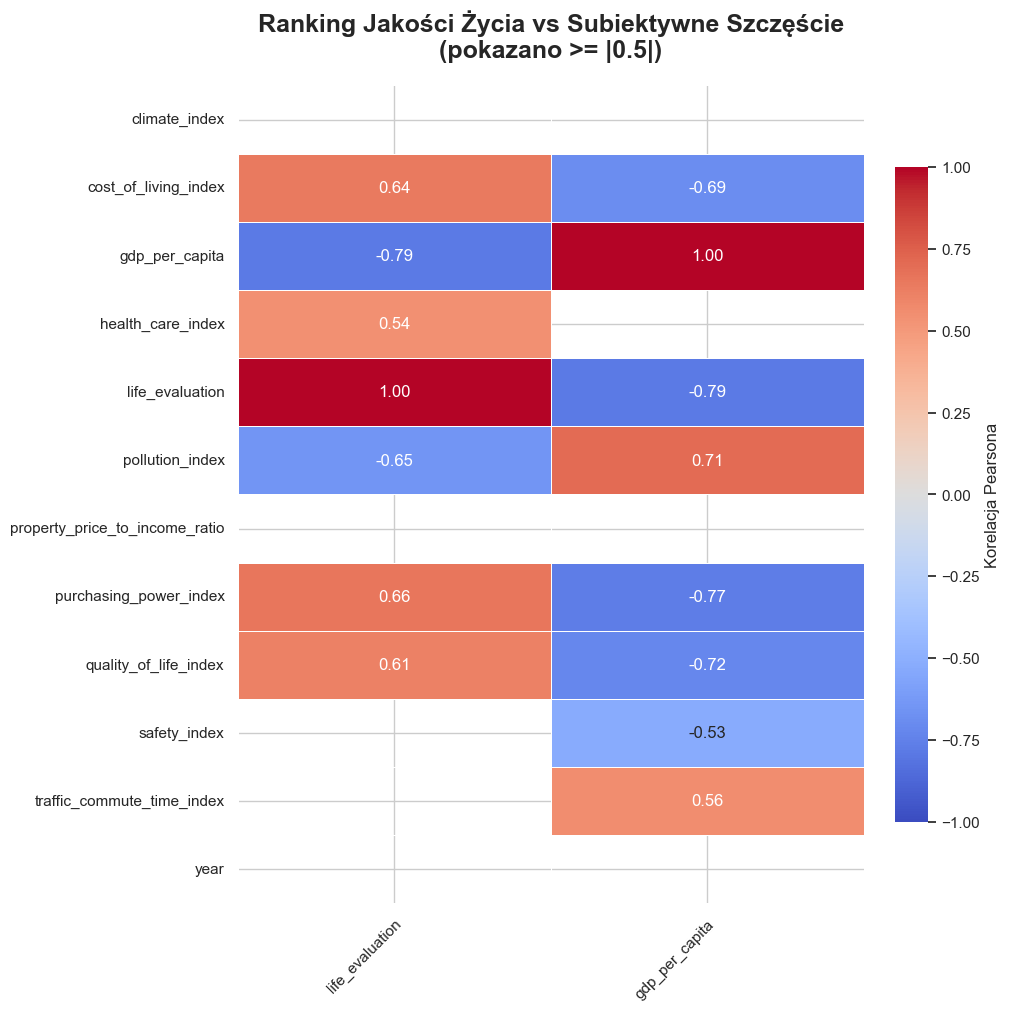

In [60]:
# ==========================================
# ANALIZA 8: Ogólna Jakość Życia
# ==========================================

tabela_korelacji(
    dane=df_base_quality, 
    kolumny=zmienne_docelowe,
    tytul="Ranking Jakości Życia vs Subiektywne Szczęście",
    rozmiar=(10, 10),
    prog_korelacji=0.5
)